# DATASCI 503, Homework 8: Support Vector Machines

Support Vector Machines (SVMs) are powerful classifiers that find the optimal separating hyperplane between classes by maximizing the margin—the distance between the decision boundary and the nearest training points. This assignment covers the **maximal margin classifier** for linearly separable data, **soft-margin SVMs** that allow some misclassification via slack variables, and **kernel methods** that enable non-linear decision boundaries by implicitly mapping data to higher-dimensional feature spaces.

---

**Problem 1 (ISLP Ch 9, Exercise 2):** Non-linear Decision Boundaries

We have seen that in $p=2$ dimensions, a linear decision boundary takes the form $\beta_0 + \beta_1 X_1 + \beta_2 X_2 = 0$. We now investigate a non-linear decision boundary.

**(a)** Sketch the curve $(1 + X_1)^2 + (2 - X_2)^2 = 4$.


The curve is a circle centered at $(-1,2)$ with radius $2$.

Equivalently,
$$
(X_1 + 1)^2 + (X_2 - 2)^2 = 4.
$$

The set
$$
(1 + X_1)^2 + (2 - X_2)^2 \le 4
$$
is the closed disk inside the circle, while
$$
(1 + X_1)^2 + (2 - X_2)^2 > 4
$$
is the exterior region outside the circle.

**(c)** Suppose that a classifier assigns an observation to the blue class if $(1 + X_1)^2 + (2 - X_2)^2 > 4$ and to the red class otherwise. To what class is the observation (0, 0) classified? (-1, 1)? (2, 2)? (3, 8)?


The points are classified as follows:
- $(0,0)$: blue, since $1^2 + 2^2 = 5 > 4$.
- $(-1,1)$: red, since $0^2 + 1^2 = 1 \le 4$.
- $(2,2)$: blue, since $3^2 + 0^2 = 9 > 4$.
- $(3,8)$: blue, since $4^2 + (-6)^2 = 52 > 4$.

**(d)** Argue that while the decision boundary in (c) is not linear in terms of $X_1$ and $X_2$, it is linear in terms of $X_1$, $X_1^2$, $X_2$, and $X_2^2$.


Expand the boundary equation:
$$
(1+X_1)^2 + (2-X_2)^2 = 4
$$
$$
X_1^2 + 2X_1 + 1 + X_2^2 - 4X_2 + 4 = 4
$$
so
$$
X_1^2 + 2X_1 + X_2^2 - 4X_2 + 1 = 0.
$$
This is linear in the transformed variables $X_1, X_1^2, X_2, X_2^2$.

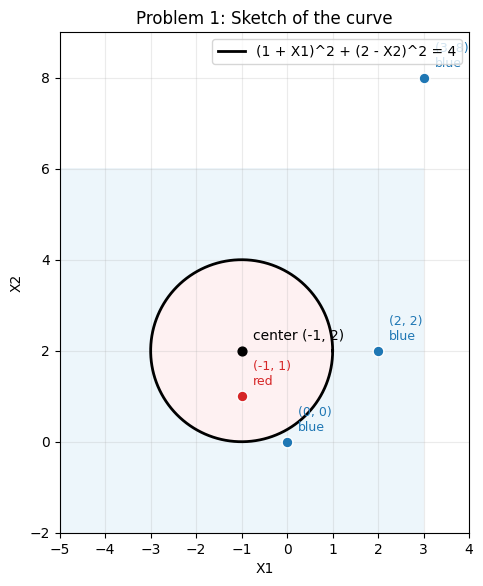

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Problem 1 sketch: (1 + X1)^2 + (2 - X2)^2 = 4
x1 = np.linspace(-5, 3, 400)
theta = np.linspace(0, 2 * np.pi, 400)
x_circle = -1 + 2 * np.cos(theta)
y_circle = 2 + 2 * np.sin(theta)

points = np.array([
    [0, 0],
    [-1, 1],
    [2, 2],
    [3, 8],
])
point_labels = ["blue", "red", "blue", "blue"]
point_colors = ["tab:blue", "tab:red", "tab:blue", "tab:blue"]

fig, ax = plt.subplots(figsize=(6.5, 6.5))

# Fill the interior and exterior regions to match the written description
x2_grid = np.linspace(-2, 6, 300)
X1, X2 = np.meshgrid(x1, x2_grid)
region = (1 + X1) ** 2 + (2 - X2) ** 2
ax.contourf(X1, X2, region, levels=[0, 4, region.max()], colors=["#fde2e4", "#d9edf7"], alpha=0.45)

ax.plot(x_circle, y_circle, color="black", linewidth=2, label="(1 + X1)^2 + (2 - X2)^2 = 4")
ax.scatter([-1], [2], color="black", s=40, zorder=3)
ax.annotate("center (-1, 2)", (-1, 2), textcoords="offset points", xytext=(8, 8))

for (x_val, y_val), label, color in zip(points, point_labels, point_colors):
    ax.scatter(x_val, y_val, color=color, s=60, edgecolor="white", zorder=4)
    ax.annotate(f"({x_val}, {y_val})\n{label}", (x_val, y_val),
                textcoords="offset points", xytext=(8, 8), fontsize=9, color=color)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title("Problem 1: Sketch of the curve")
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-5, 4)
ax.set_ylim(-2, 9)
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right")
plt.show()

---

**Problem 2 (ISLP Ch 9, Exercise 3):** Maximal Margin Classifier

**(a)** We are given $n = 7$ observations in $p = 2$ dimensions. For each observation, there is an associated class label.

| Obs. | $X_1$ | $X_2$ | $Y$ |
|------|-------|-------|-----|
| 1 | 3 | 4 | Red |
| 2 | 2 | 2 | Red |
| 3 | 4 | 4 | Red |
| 4 | 1 | 4 | Red |
| 5 | 2 | 1 | Blue |
| 6 | 4 | 3 | Blue |
| 7 | 4 | 1 | Blue |

Sketch these points on a graph.


A sketch would place the red points at $(3,4)$, $(2,2)$, $(4,4)$, and $(1,4)$, and the blue points at $(2,1)$, $(4,3)$, and $(4,1)$.

Visually, the red class lies mostly above and to the left of the blue class.

**(b)** Sketch the optimal separating hyperplane, and provide the equation for this hyperplane in the form $\beta_0 + \beta_1 X_1 + \beta_2 X_2 = 0$.


One separating hyperplane is
$$
1 - 2X_1 + 2X_2 = 0,
$$
equivalently
$$
X_2 = X_1 - \tfrac{1}{2}.
$$

**(c)** Describe the classification rule for the maximal margin classifier. It should be something along the lines of "Classify to Red if $\beta_0 + \beta_1 X_1 + \beta_2 X_2 > 0$, and classify to Blue otherwise." Provide the values for $\beta_0$, $\beta_1$, and $\beta_2$.


A valid classification rule is
$$
\text{Classify to Red if } 1 - 2X_1 + 2X_2 > 0, \text{ and to Blue otherwise.}
$$
Thus one choice is
$$
\beta_0 = 1,\quad \beta_1 = -2,\quad \beta_2 = 2.
$$

**(d)** On your sketch, indicate the margin for the maximal margin hyperplane.


The margin lines are
$$
1 - 2X_1 + 2X_2 = 1
\quad\text{and}\quad
1 - 2X_1 + 2X_2 = -1.
$$
Equivalently,
$$
X_2 = X_1
\quad\text{and}\quad
X_2 = X_1 - 1.
$$

**(e)** Indicate the support vectors for the maximal margin classifier.


The support vectors are the observations closest to the separating line:
- Red: observations 2 and 3, $(2,2)$ and $(4,4)$.
- Blue: observations 5 and 6, $(2,1)$ and $(4,3)$.

**(f)** Argue that a slight movement of the seventh observation would not affect the maximal margin hyperplane.


The seventh observation is not a support vector, so a small movement of it does not change the optimal separating hyperplane.

Only the support vectors determine the position of the maximal margin hyperplane.

**(g)** Sketch a hyperplane that is not the optimal separating hyperplane, and provide the equation for this hyperplane.


One non-optimal separating hyperplane is
$$
X_2 = X_1 - 2
$$
which still separates the classes but leaves a smaller margin than the optimal hyperplane.

**(h)** Draw an additional observation on the plot so that the two classes are no longer separable by a hyperplane.


One additional observation such as $(3,2)$, labeled Blue, would make the classes non-separable by a hyperplane.

It would lie inside the red cluster and destroy linear separability.

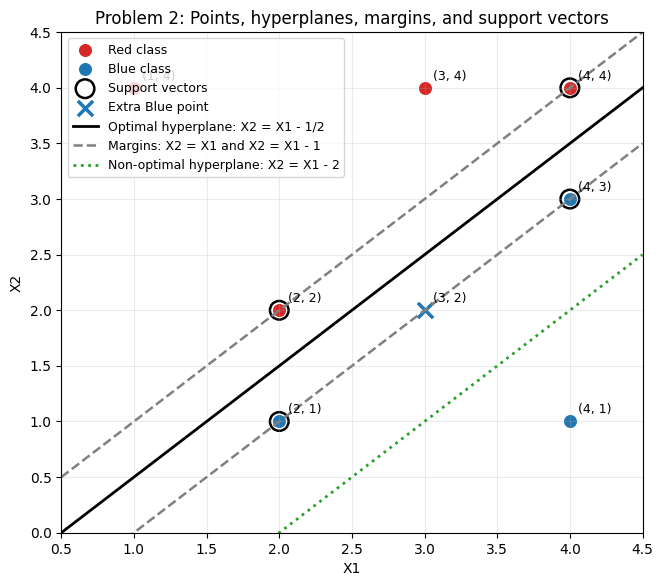

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Problem 2 visual summary
red_points = np.array([[3, 4], [2, 2], [4, 4], [1, 4]])
blue_points = np.array([[2, 1], [4, 3], [4, 1]])
support_red = np.array([[2, 2], [4, 4]])
support_blue = np.array([[2, 1], [4, 3]])
extra_blue = np.array([3, 2])
x1 = np.linspace(0.5, 4.5, 300)

optimal = x1 - 0.5
margin_upper = x1
margin_lower = x1 - 1
nonoptimal = x1 - 2

fig, ax = plt.subplots(figsize=(7.5, 6.5))

ax.scatter(red_points[:, 0], red_points[:, 1], color="tab:red", s=70, label="Red class")
ax.scatter(blue_points[:, 0], blue_points[:, 1], color="tab:blue", s=70, label="Blue class")

for x_val, y_val in red_points:
    ax.annotate(f"({x_val}, {y_val})", (x_val, y_val), textcoords="offset points", xytext=(6, 6), fontsize=9)
for x_val, y_val in blue_points:
    ax.annotate(f"({x_val}, {y_val})", (x_val, y_val), textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.scatter(support_red[:, 0], support_red[:, 1], s=180, facecolors="none", edgecolors="black", linewidths=1.8, label="Support vectors")
ax.scatter(support_blue[:, 0], support_blue[:, 1], s=180, facecolors="none", edgecolors="black", linewidths=1.8)
ax.scatter(extra_blue[0], extra_blue[1], color="tab:blue", marker="x", s=120, linewidths=2.5, label="Extra Blue point")
ax.annotate("(3, 2)", extra_blue, textcoords="offset points", xytext=(6, 6), fontsize=9)

ax.plot(x1, optimal, color="black", linewidth=2, label="Optimal hyperplane: X2 = X1 - 1/2")
ax.plot(x1, margin_upper, color="gray", linestyle="--", linewidth=1.8, label="Margins: X2 = X1 and X2 = X1 - 1")
ax.plot(x1, margin_lower, color="gray", linestyle="--", linewidth=1.8)
ax.plot(x1, nonoptimal, color="tab:green", linestyle=":", linewidth=2, label="Non-optimal hyperplane: X2 = X1 - 2")

ax.set_xlim(0.5, 4.5)
ax.set_ylim(0.0, 4.5)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title("Problem 2: Points, hyperplanes, margins, and support vectors")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", fontsize=9)
plt.show()

---

**Problem 3:** SVM Margins and Slack Variables

For this question, use graph paper, a drawing application, or Python.

**(a)** Suppose

$$f(X_1, X_2) = \frac{1}{\sqrt{2}}X_1 - \frac{1}{\sqrt{2}}X_2 - 1$$

Draw the hyperplane defined by $f(X_1, X_2) = 0$. Indicate the region of possible inputs $X_1, X_2$ for which $f(X_1, X_2) > 0$ with a "+" sign. Indicate the region of possible inputs $X_1, X_2$ for which $f(X_1, X_2) < 0$ with a "-" sign.


The decision boundary is
$$
\frac{1}{\sqrt{2}}X_1 - \frac{1}{\sqrt{2}}X_2 - 1 = 0,
$$
or equivalently
$$
X_1 - X_2 = \sqrt{2}.
$$
Thus $f(X_1,X_2)>0$ on the side where $X_1 - X_2 > \sqrt{2}$, and $f(X_1,X_2)<0$ on the opposite side.

**(b)** Suppose an SVM classifier is fit to data, resulting in the following decision rule:

$$
\hat{y}(X_1, X_2) = 
\begin{cases}
    + & \text{if } f(X_1, X_2) > 0 \\
    - & \text{if } f(X_1, X_2) \leq 0
\end{cases}
$$

Suppose further that this SVM is associated with a margin of $m = \sqrt{2}$. Draw the margin lines.


The margin lines are given by
$$
f(X_1,X_2) = \pm \sqrt{2}.
$$
So the two lines are
$$
\frac{1}{\sqrt{2}}X_1 - \frac{1}{\sqrt{2}}X_2 - 1 = \sqrt{2}
\quad\text{and}\quad
\frac{1}{\sqrt{2}}X_1 - \frac{1}{\sqrt{2}}X_2 - 1 = -\sqrt{2}.
$$

**(c)** What class label (+ or -, as defined above) does this SVM predict for the following points: (1, 4); (1, 1); (2, -5); (2, -1); (4, 2)?


Evaluating the sign of $f(X_1,X_2)$ gives:
- $(1,4)$: $-$
- $(1,1)$: $-$
- $(2,-5)$: $+$
- $(2,-1)$: $+$
- $(4,2)$: $+$

**(d)** Suppose that these five points were part of the training data, and their true labels, given in the same order, are -, -, +, +, -. Calculate the corresponding slack values ($\xi_i$) for each of the five points.


Using the standard slack definition
$$
\xi_i = \max\{0, 1 - y_i f(x_i)\},
$$
with $+$ as $+1$ and $-$ as $-1$, the slack values are:
$$
\xi_1 = 0,\quad \xi_2 = 0,\quad \xi_3 = 0,\quad \xi_4 = 0,\quad \xi_5 = \sqrt{2}.
$$

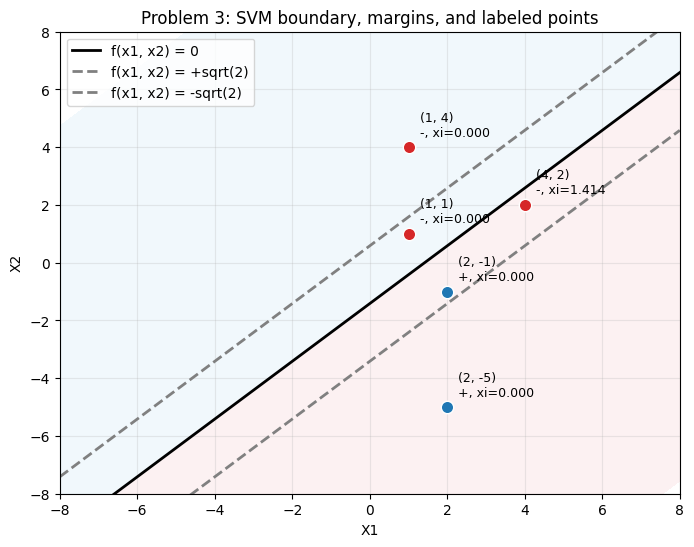

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Problem 3 illustration: decision boundary, margins, and sample points
x1 = np.linspace(-8, 8, 400)

# Decision boundary and margin lines from f(x1, x2) = (x1 - x2)/sqrt(2) - 1
boundary = x1 - np.sqrt(2)
margin_plus = x1 - np.sqrt(2) - 2
margin_minus = x1 - np.sqrt(2) + 2

points = np.array([
    [1, 4],
    [1, 1],
    [2, -5],
    [2, -1],
    [4, 2],
])
labels = np.array(["-", "-", "+", "+", "-"])
slacks = np.array([0, 0, 0, 0, np.sqrt(2)])

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(x1, boundary, color="black", linewidth=2, label="f(x1, x2) = 0")
ax.plot(x1, margin_plus, color="gray", linestyle="--", linewidth=2, label="f(x1, x2) = +sqrt(2)")
ax.plot(x1, margin_minus, color="gray", linestyle="--", linewidth=2, label="f(x1, x2) = -sqrt(2)")

# Shade the positive and negative sides of the decision boundary
x2_grid = np.linspace(-8, 8, 300)
X1, X2 = np.meshgrid(x1, x2_grid)
F = X1 / np.sqrt(2) - X2 / np.sqrt(2) - 1
ax.contourf(X1, X2, F, levels=[-10, 0, 10], colors=["#d9edf7", "#f8d7da"], alpha=0.35)

for (x_val, y_val), label, slack in zip(points, labels, slacks):
    color = "tab:blue" if label == "+" else "tab:red"
    ax.scatter(x_val, y_val, s=80, color=color, edgecolor="white", zorder=3)
    ax.annotate(f"({x_val}, {y_val})\n{label}, xi={slack:.3f}", (x_val, y_val),
                textcoords="offset points", xytext=(8, 8), fontsize=9)

ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title("Problem 3: SVM boundary, margins, and labeled points")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.25)
plt.show()

---

**Problem 4:** SVM on Crabs Data

This question uses the `crabs.csv` data, with the five body measurements (`FL`, `RW`, `CL`, `CW`, `BD`) as predictors and species (`sp`) as the response. Omit all other variables including sex. We will assess error using misclassification rate.

**Hint:** Use [`sklearn.svm.SVC`](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) with appropriate kernels. Use [`sklearn.model_selection.cross_val_score`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) or manual K-fold cross-validation to estimate error. Remember to scale your features using [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

**(a)** Fit a linear SVM to the data for a range of values of the C hyperparameter, to predict species from the five numerical measurements. Plot the cross-validated estimate of the error as a function of C.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Load data and create train/test sets
crabs_df = pd.read_csv("crabs.csv", index_col=0)
features = crabs_df[["FL", "RW", "CL", "CW", "BD"]]
target = crabs_df["sp"]

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.25, random_state=42
)

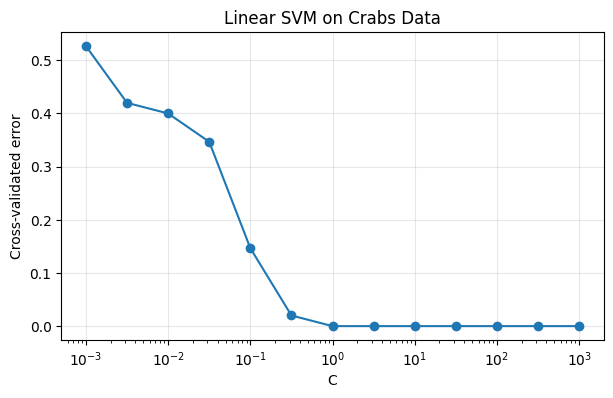

In [3]:
# Cross-validated linear SVM error over a range of C values
c_values = np.logspace(-3, 3, 13)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_errors_linear = []

for c_value in c_values:
    linear_svm = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="linear", C=c_value)),
    ])
    scores = cross_val_score(linear_svm, X_train, y_train, cv=cv, scoring="accuracy")
    cv_errors_linear.append(1 - scores.mean())

plt.figure(figsize=(7, 4))
plt.plot(c_values, cv_errors_linear, marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Cross-validated error")
plt.title("Linear SVM on Crabs Data")
plt.grid(True, alpha=0.3)
plt.show()

In [4]:
# Test assertions
assert len(cv_errors_linear) == len(c_values), "Should have error for each C value"
assert all(0 <= err <= 1 for err in cv_errors_linear), "Errors should be between 0 and 1"
print("All tests passed!")

All tests passed!


**(b)** Now, fit nonlinear SVMs with polynomial kernels. Consider at least three values of degree. For each one, plot the cross-validated estimate of the error as a function of C.

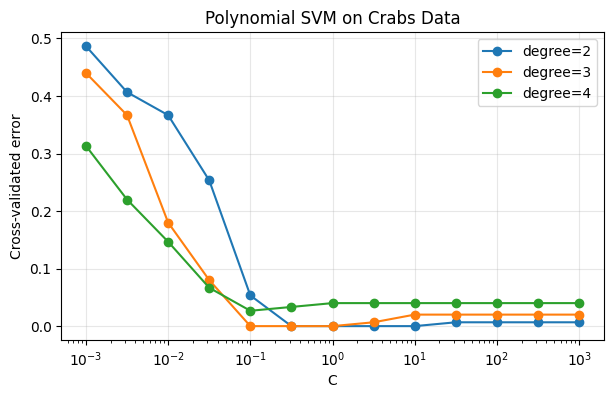

In [5]:
# Polynomial-kernel SVM cross-validated errors
c_values = np.logspace(-3, 3, 13)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

degrees = [2, 3, 4]
cv_errors_poly = {}

plt.figure(figsize=(7, 4))

for degree in degrees:
    errors = []
    for c_value in c_values:
        poly_svm = Pipeline([
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="poly", degree=degree, coef0=1.0, gamma=1.0, C=c_value)),
        ])
        scores = cross_val_score(poly_svm, X_train, y_train, cv=cv, scoring="accuracy")
        errors.append(1 - scores.mean())

    cv_errors_poly[degree] = errors
    plt.plot(c_values, errors, marker="o", label=f"degree={degree}")

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Cross-validated error")
plt.title("Polynomial SVM on Crabs Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Test assertions
assert len(cv_errors_poly) >= 3, "Should test at least 3 polynomial degrees"
assert all(
    len(errors) == len(c_values) for errors in cv_errors_poly.values()
), "Should have error for each C value"
print("All tests passed!")

All tests passed!


**(c)** Finally, fit nonlinear SVMs with radial (RBF) kernels. Consider at least three values of gamma. For each one, plot the cross-validated estimate of the error as a function of C.

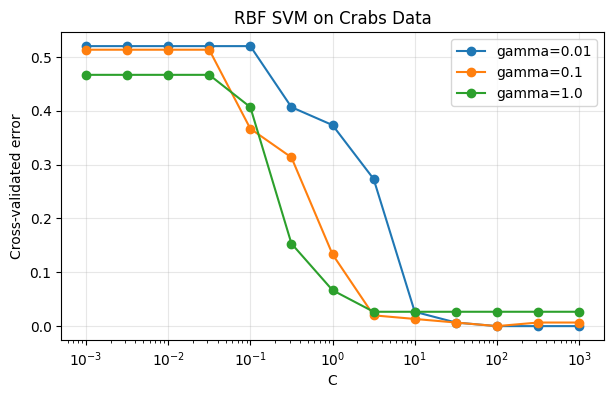

In [7]:
gamma_values = [0.01, 0.1, 1.0]
cv_errors_rbf = {}

plt.figure(figsize=(7, 4))

for gamma in gamma_values:
    errors = []
    for c_value in c_values:
        rbf_svm = Pipeline([
            ("scaler", StandardScaler()),
            ("svc", SVC(kernel="rbf", gamma=gamma, C=c_value)),
        ])
        scores = cross_val_score(rbf_svm, X_train, y_train, cv=cv, scoring="accuracy")
        errors.append(1 - scores.mean())

    cv_errors_rbf[gamma] = errors
    plt.plot(c_values, errors, marker="o", label=f"gamma={gamma}")

plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Cross-validated error")
plt.title("RBF SVM on Crabs Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [8]:
# Test assertions
assert len(cv_errors_rbf) >= 3, "Should test at least 3 gamma values"
assert all(
    len(errors) == len(c_values) for errors in cv_errors_rbf.values()
), "Should have error for each C value"
print("All tests passed!")

All tests passed!
